In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from matplotlib.colors import LogNorm

In [62]:
files = glob('../data/*.csv')
print(files)
file = files[2]
print(file)
data = pd.read_csv(
    file, header=3
    )

file.split('_')

p = 10.0
e = float(file.split('_')[1][1:])
a = float(file.split('_')[2][1:])
n = int(file.split('_')[3].split('.')[0][1:])

r_min = p / (1 + e)   # periastron
r_max = p / (1 - e)   # apastron

['../data/scan_e0.6_a0.8_n2.csv', '../data/scan_e0.1_a0.2_n2.csv', '../data/scan_e0.3_a0.5_n2.csv', '../data/scan_e0.3_a0.5_n15.csv']
../data/scan_e0.3_a0.5_n2.csv


In [69]:
r, th, err = data[(data["N"] == 256)&(data["method"]=="trap")][["rField", "theta", "err_max"]].to_numpy().T

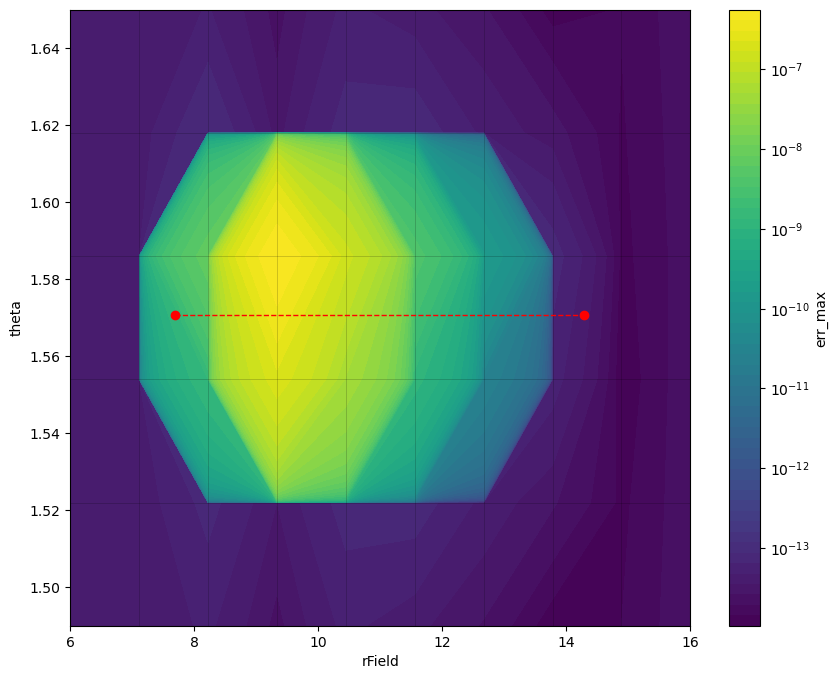

In [71]:
# regular grid -> reshape
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

ru, thu = np.unique(r), np.unique(th)
R, TH = np.meshgrid(ru, thu, indexing='ij')
E = err.reshape(len(ru), len(thu))

fig, ax = plt.subplots(figsize=(10,8))
cf = ax.contourf(R, TH, E, levels=np.logspace(np.log10(err.min()), np.log10(err.max()), 60),
                 norm=LogNorm(), cmap='viridis')
fig.colorbar(cf, label='err_max',
             ticks=LogLocator(numticks=12),
             format=LogFormatterSciNotation())
# faint grid at sample locations
ax.vlines(ru, thu.min(), thu.max(), color='k', lw=0.4, alpha=0.3)
ax.hlines(thu, ru.min(), ru.max(), color='k', lw=0.4, alpha=0.3)
ax.hlines(np.pi/2, r_min, r_max, color='r', ls='--', lw=1)
ax.scatter([r_min,r_max],[np.pi/2, np.pi/2], c='r')
ax.set_xlabel('rField'); ax.set_ylabel('theta')
plt.show()